# 03 — Monte Carlo Simulation
Estimating portfolio risk by simulating thousands of possible future return paths.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (12, 6)

np.random.seed(42)

In [2]:
returns = pd.read_csv("../data/returns.csv", index_col=0, parse_dates=True)

n = len(returns.columns)
weights = np.array([1/n] * n)

portfolio_returns = returns.dot(weights)
print(f"Loaded {len(portfolio_returns)} days of portfolio returns")

Loaded 1257 days of portfolio returns


In [3]:
n_simulations = 10000
n_days = 1  # 1-day horizon for VaR comparison

mu = portfolio_returns.mean()
sigma = portfolio_returns.std()

print(f"Mean daily return: {mu:.4%}")
print(f"Daily volatility:  {sigma:.4%}")
print(f"Running {n_simulations:,} simulations...")

Mean daily return: 0.0633%
Daily volatility:  1.2432%
Running 10,000 simulations...


In [4]:
simulated_returns = np.random.normal(mu, sigma, n_simulations)

mc_var_95 = np.percentile(simulated_returns, 5)
mc_var_99 = np.percentile(simulated_returns, 1)
mc_cvar_95 = simulated_returns[simulated_returns <= mc_var_95].mean()
mc_cvar_99 = simulated_returns[simulated_returns <= mc_var_99].mean()

print("=== Monte Carlo VaR & CVaR ===")
print(f"  95% VaR:  {mc_var_95:.4%}  |  CVaR: {mc_cvar_95:.4%}")
print(f"  99% VaR:  {mc_var_99:.4%}  |  CVaR: {mc_cvar_99:.4%}")

=== Monte Carlo VaR & CVaR ===
  95% VaR:  -1.9941%  |  CVaR: -2.5169%
  99% VaR:  -2.8217%  |  CVaR: -3.2895%


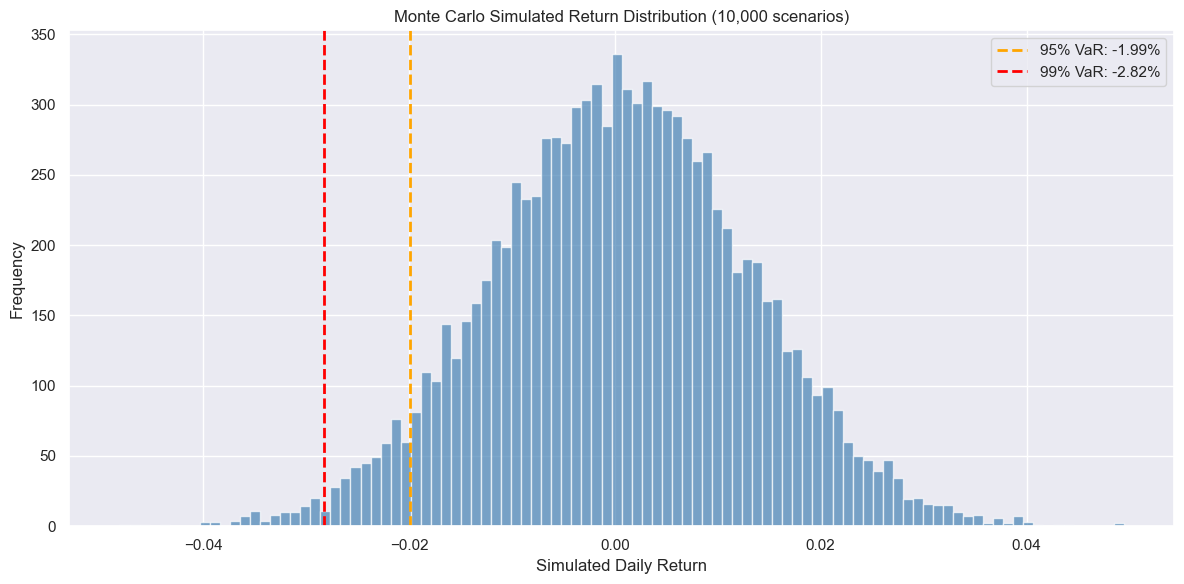

In [5]:
plt.figure(figsize=(12, 6))
plt.hist(simulated_returns, bins=100, color="steelblue", edgecolor="white", alpha=0.7)
plt.axvline(mc_var_95, color="orange", linestyle="--", linewidth=2, label=f"95% VaR: {mc_var_95:.2%}")
plt.axvline(mc_var_99, color="red", linestyle="--", linewidth=2, label=f"99% VaR: {mc_var_99:.2%}")
plt.title("Monte Carlo Simulated Return Distribution (10,000 scenarios)")
plt.xlabel("Simulated Daily Return")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/monte_carlo_distribution.png", dpi=150)
plt.show()

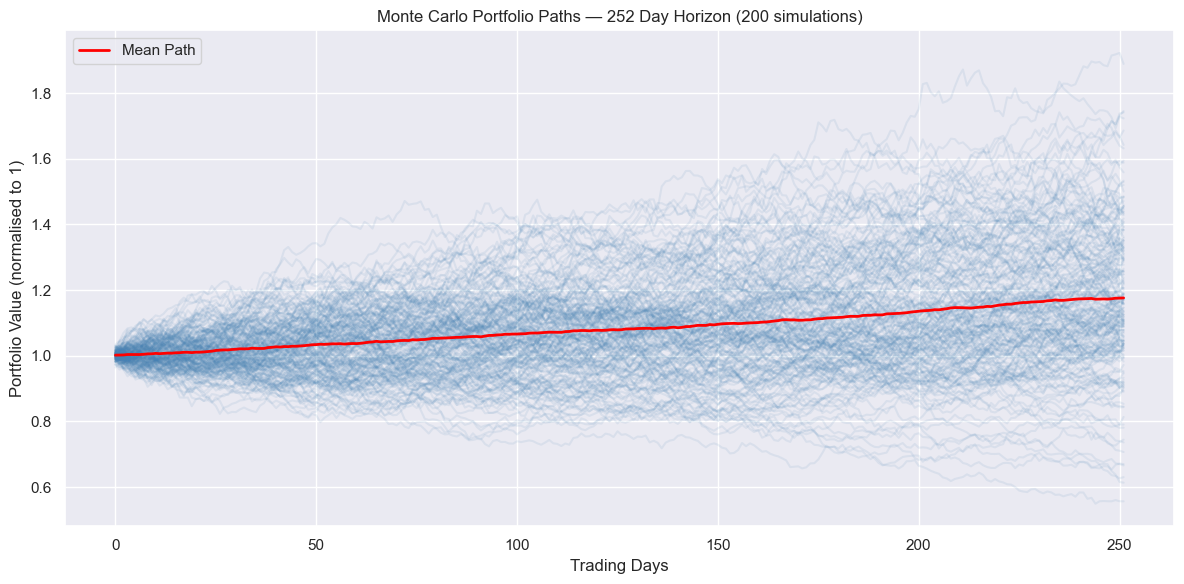

In [6]:
n_paths = 200
n_days_ahead = 252  # 1 trading year

simulated_paths = np.zeros((n_days_ahead, n_paths))

for i in range(n_paths):
    daily = np.random.normal(mu, sigma, n_days_ahead)
    simulated_paths[:, i] = np.cumprod(1 + daily)

plt.figure(figsize=(12, 6))
plt.plot(simulated_paths, alpha=0.1, color="steelblue")
plt.plot(np.mean(simulated_paths, axis=1), color="red", linewidth=2, label="Mean Path")
plt.title("Monte Carlo Portfolio Paths — 252 Day Horizon (200 simulations)")
plt.xlabel("Trading Days")
plt.ylabel("Portfolio Value (normalised to 1)")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/monte_carlo_paths.png", dpi=150)
plt.show()

In [7]:
hist_var_95 = np.percentile(portfolio_returns, 5)
hist_cvar_95 = portfolio_returns[portfolio_returns <= hist_var_95].mean()
param_var_95 = norm.ppf(0.05, mu, sigma)
param_cvar_95 = mu - sigma * norm.pdf(norm.ppf(0.95)) / 0.05

comparison = pd.DataFrame({
    "Method": ["Historical", "Parametric", "Monte Carlo"],
    "95% VaR": [f"{hist_var_95:.4%}", f"{param_var_95:.4%}", f"{mc_var_95:.4%}"],
    "95% CVaR": [f"{hist_cvar_95:.4%}", f"{param_cvar_95:.4%}", f"{mc_cvar_95:.4%}"]
}).set_index("Method")

comparison.to_csv("../data/method_comparison.csv")
print("✅ Saved method_comparison.csv")
comparison

✅ Saved method_comparison.csv


,95% VaR,95% CVaR
Method,,
Historical,-1.6193%,-2.9679%
Parametric,-1.9817%,-2.5012%
Monte Carlo,-1.9941%,-2.5169%
